Import libraries

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import seaborn as sns


Load Dataset

In [14]:

data_dir = "Dataset"
img_size = (64, 64)
batch_size = 32

#dividing dataset such that 
# 70% training set
# 15% validation set
# 15% testing set

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.3, 
    subset="training",
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

# 30% temp (will be split into val & test)
temp_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.3,
    subset="validation",
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

#Now split temp_ds into 50% val + 50% test => 15% of total dataset each
val_size = 0.5
val_ds = temp_ds.take(int(len(temp_ds) * val_size))
test_ds = temp_ds.skip(int(len(temp_ds) * val_size))

#Normalize(for scaling pixel values btw 0 and 1)
normalization_layer = layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

#Prefetch for speed(to load data while the model is training on the current batch)
train_ds = train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

#batching 32 images per batch
print("Train batches:", len(train_ds))
print("Validation batches:", len(val_ds))
print("Test batches:", len(test_ds))


Found 2062 files belonging to 10 classes.
Using 1444 files for training.
Found 2062 files belonging to 10 classes.
Using 618 files for validation.
Train batches: 46
Validation batches: 10
Test batches: 10


Build CNN Model

In [ ]:
#regularization l2 penalizes large weights or small weights to prevent overfitting and underfitting

model = models.Sequential([
    #layer 1
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3),
                  kernel_regularizer=regularizers.l2(0.001)),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25), 

    #layer 2
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    #layer 3
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    #output layer
    layers.Dense(10, activation='softmax')
])
#dropout is randomly setting few percentage of newurons to zero during training to prevent overfitting
#dense layer is for making final classification
model.summary()


c:\Users\kasha\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,626,442 (6.20 MB)

 Trainable params: 1,626,442 (6.20 MB)

 Non-trainable params: 0 (0.00 B)

Compile & Early Stopping

In [ ]:
#adm adapt learning rate automatically
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy', #as labels are 0-9
    metrics=['accuracy']
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5, #how many epochs to wait after last time val_loss improved
    restore_best_weights=True
)


Train Model

In [17]:
#here models gets trained
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop]
)


Epoch 1/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.1018 - loss: 2.3643 - val_accuracy: 0.2000 - val_loss: 2.3004
Epoch 2/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.1835 - loss: 2.2273 - val_accuracy: 0.4344 - val_loss: 1.9790
Epoch 3/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.4508 - loss: 1.5921 - val_accuracy: 0.7031 - val_loss: 1.0751
Epoch 4/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.5880 - loss: 1.1503 - val_accuracy: 0.7594 - val_loss: 0.7916
Epoch 5/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.6593 - loss: 0.9766 - val_accuracy: 0.7750 - val_loss: 0.6882
Epoch 6/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.6988 - loss: 0.8832 - val_accuracy: 0.8375 - val_loss: 0.5778
Epoch 7/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.7348 - loss: 0.7611 - val_accuracy: 0.8844 - val_loss: 0.4499
Epoch 8/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.7770 - loss: 0.6476 - val_accuracy: 0.8813 - v

Accuracy & Loss Curves

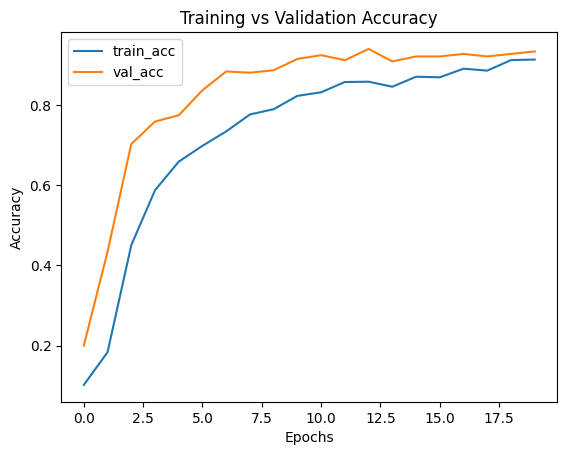

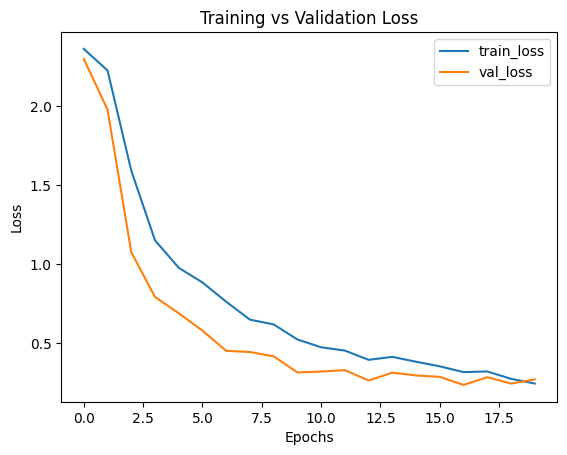

In [19]:
plt.plot(history.history['accuracy'], label="train_acc")
plt.plot(history.history['val_accuracy'], label="val_acc")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()


plt.plot(history.history['loss'], label="train_loss")
plt.plot(history.history['val_loss'], label="val_loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()


Evaluate on Test Set

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9329 - loss: 0.2317 
Test Accuracy: 0.9328858852386475
Test Loss: 0.23172007501125336


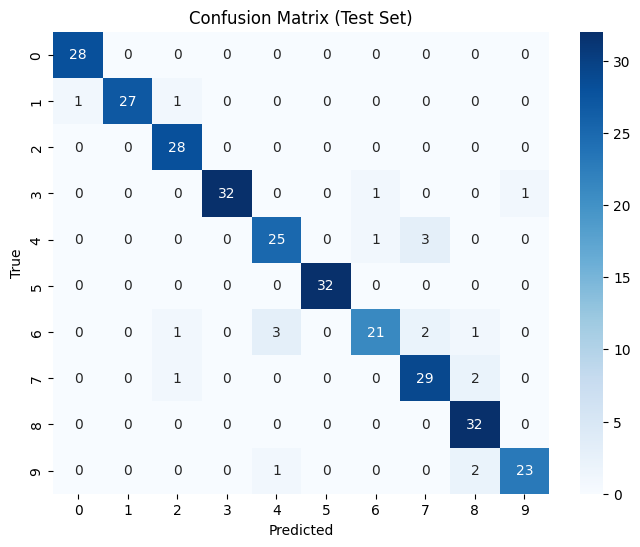

              precision    recall  f1-score   support

           0       0.97      1.00      0.98        28
           1       1.00      0.93      0.96        29
           2       0.90      1.00      0.95        28
           3       1.00      0.94      0.97        34
           4       0.86      0.86      0.86        29
           5       1.00      1.00      1.00        32
           6       0.91      0.75      0.82        28
           7       0.85      0.91      0.88        32
           8       0.86      1.00      0.93        32
           9       0.96      0.88      0.92        26

    accuracy                           0.93       298
   macro avg       0.93      0.93      0.93       298
weighted avg       0.93      0.93      0.93       298



In [ ]:
# Evaluate on test set
test_loss, test_acc = model.evaluate(test_ds)
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

#Predictions
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Test Set)")
plt.show()

# Precision, Recall, F1
print(classification_report(y_true, y_pred))


AUC-ROC (Test Set)

In [ ]:
y_probs = []
for images, labels in test_ds:
    probs = model.predict(images, verbose=0)
    y_probs.extend(probs)

y_probs = np.array(y_probs)
y_true_onehot = tf.keras.utils.to_categorical(y_true, num_classes=10)

auc = roc_auc_score(y_true_onehot, y_probs, multi_class="ovr")
print("AUC-ROC (Test Set):", auc)

#this eans that 47% of the time this model is able to distinguish between classes correctly

AUC-ROC (Test Set): 0.47838889674262963
